# 02 Point Forecast Baselines

这个 notebook 整理最终 5 条月度点预测基线：Baseline 1、Baseline 2、Baseline 3、Baseline 4 和 AK-D。公开版使用合成样例数据跑通流程，并用脱敏真实指标做结果分析。

## 1. Data Description

输入包括月度真值、气象预报、功率曲线和 AK-D 分月订正系数。真实项目中的 EC45、ERA5、SCADA 和月度理论电量不会上传；公开样例只保留字段结构。

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wind_power_baselines.baselines import build_all_baselines
from wind_power_baselines.evaluation import evaluate_predictions, normalize_public_predictions
from wind_power_baselines.preprocessing import clean_monthly_truth, prepare_forecast

sns.set_theme(style='whitegrid')
truth = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_monthly_truth.csv')
forecast_raw = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_weather_forecast.csv')
power_curve = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_power_curve.csv')
correction = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_ak_monthly_correction.csv')
truth.head(), forecast_raw.head(), power_curve.head(), correction.head()

(     month  energy_true
 0  2024-01     1340.000
 1  2024-02     1311.637
 2  2024-03     1222.941
 3  2024-04     1099.412
 4  2024-05      975.882,
    issue_time target_time  lead_day  wind_speed
 0  2024-12-16  2025-01-01        16       6.804
 1  2024-12-16  2025-01-02        17       7.136
 2  2024-12-16  2025-01-03        18       7.375
 3  2024-12-16  2025-01-04        19       5.843
 4  2024-12-16  2025-01-05        20       6.699,
   turbine_id  season  wind_speed_bin  power_kw  sample_count
 0        T01  winter             4.5    30.304            20
 1        T01  winter             5.0    39.638            31
 2        T01  winter             5.5    80.716            28
 3        T01  winter             6.0   157.488            33
 4        T01  winter             6.5   180.896            31,
      month  correction_factor
 0  2025-01               0.92
 1  2025-02               0.98
 2  2025-03               1.04
 3  2025-04               1.06
 4  2025-05               

## 2. Cleaning And Preprocessing

这里完成月份标准化、时间解析、风速合法性检查、预测提前期检查和预测月份对齐。公开样例故意保持简单，重点是展示真实工程里需要固定的数据契约。

In [2]:
truth_clean = clean_monthly_truth(truth)
forecast = prepare_forecast(forecast_raw)
print({'truth_months': len(truth_clean), 'forecast_rows': len(forecast), 'forecast_months': forecast['month'].nunique()})
forecast.head()

{'truth_months': 18, 'forecast_rows': 181, 'forecast_months': 6}


,issue_time,target_time,lead_day,wind_speed,month,issue_month,season
0,2024-12-16,2025-01-01,16,6.804,2025-01,2024-12,winter
1,2024-12-16,2025-01-02,17,7.136,2025-01,2024-12,winter
2,2024-12-16,2025-01-03,18,7.375,2025-01,2024-12,winter
3,2024-12-16,2025-01-04,19,5.843,2025-01,2024-12,winter
4,2024-12-16,2025-01-05,20,6.699,2025-01,2024-12,winter


## 3. EDA

EDA 先回答三个问题：真值有没有季节性，预报风速覆盖哪些月份，功率曲线是否能覆盖样例风速范围。

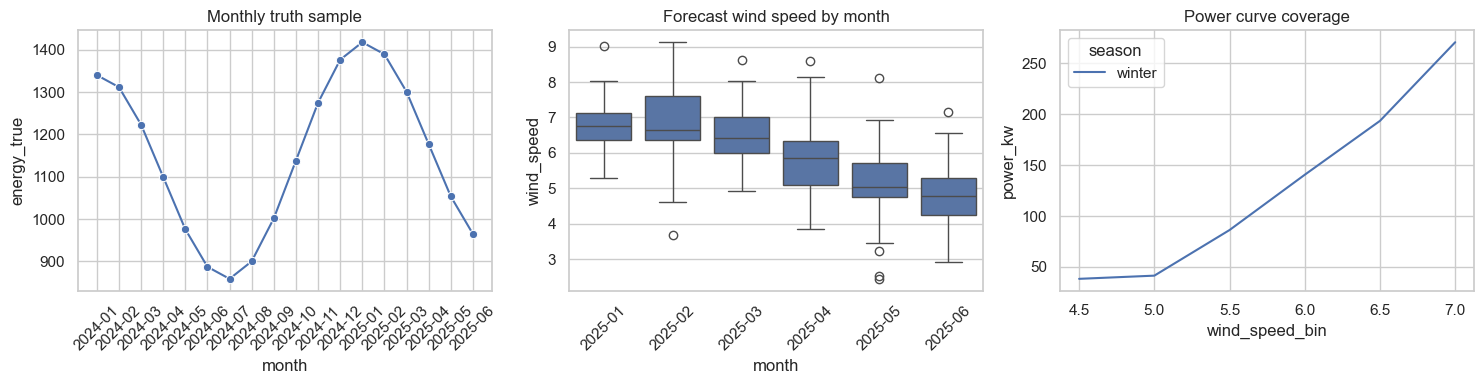

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.lineplot(data=truth_clean, x='month', y='energy_true', marker='o', ax=axes[0])
sns.boxplot(data=forecast, x='month', y='wind_speed', ax=axes[1])
sns.lineplot(data=power_curve, x='wind_speed_bin', y='power_kw', hue='season', estimator='mean', errorbar=None, ax=axes[2])
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)
axes[0].set_title('Monthly truth sample')
axes[1].set_title('Forecast wind speed by month')
axes[2].set_title('Power curve coverage')
fig.tight_layout()

## 4. Baseline Methods

- Baseline 1：历史同期电量均值，作为无气象信息的朴素基线。
- Baseline 2：ERA5/气候库思想，先用功率曲线得到历史电量库，再取 P50。
- Baseline 3：EC45 + LLS 订正 + 功率曲线，强调中长期预报风速到电量的映射。
- Baseline 4：EC45 + 相似日/覆盖优选 + 功率曲线，强调从历史相似状态借用电量水平。
- AK-D：分月订正 AK 方法，把订正系数按月份拆开，用来缓解全年同一订正系数导致的小风月高估和大风月低估。

In [4]:
predictions = build_all_baselines(truth_clean, forecast, power_curve, correction)
predictions

,method,month,energy_pred,energy_true
0,Baseline 1,2025-05,975.882000,1053.529
1,Baseline 1,2025-06,887.186000,964.833
2,Baseline 2,2025-05,114071.710452,1053.529
3,Baseline 2,2025-06,114071.710452,964.833
4,Baseline 3,2025-05,61378.749677,1053.529
5,Baseline 3,2025-06,48216.600000,964.833
6,Baseline 4,2025-05,1417.647000,1053.529
7,Baseline 4,2025-06,1417.647000,964.833
8,AK-D,2025-05,62606.324671,1053.529
9,AK-D,2025-06,46287.936000,964.833


## 5. Evaluation

统一计算 MAPE、汇总偏差和 PearsonR。真实评估中还会按 W1/W2/W3 等窗口拆分；公开样例只演示接口，真实结果在 `results_public` 中以脱敏形式给出。

In [5]:
metrics = evaluate_predictions(predictions)
public_predictions = normalize_public_predictions(predictions)
metrics, public_predictions.head()

(       method  month_count  mape_percent  bias_percent  pearson_r
 0  Baseline 1            2        7.7089       -7.6941        1.0
 1  Baseline 2            2    11225.2651    11203.3946        NaN
 2  Baseline 3            2     5311.7090     5329.9154        1.0
 3  Baseline 4            2       40.7468       40.4750        NaN
 4        AK-D            2     5270.0210     5295.1799        1.0,
        method    month  energy_true_index  energy_pred_index  error_percent
 0  Baseline 1  2025-05             1.0439             0.9670        -7.3702
 1  Baseline 1  2025-06             0.9561             0.8791        -8.0477
 2  Baseline 2  2025-05             1.0439           113.0339     10727.5814
 3  Baseline 2  2025-06             0.9561           113.0339     11722.9487
 4  Baseline 3  2025-05             1.0439            60.8204      5726.0143)

## 6. Public Result Analysis

下面读取真实工程脱敏后的结果。这里不展示真实 kWh/GWh，只展示每个方法在自身可用月份上的 MAPE、Bias、PearsonR，以及逐月归一化指数。

In [6]:
public_metrics = pd.read_csv(PROJECT_ROOT / 'results_public' / 'public_metrics_summary.csv')
public_monthly = pd.read_csv(PROJECT_ROOT / 'results_public' / 'public_monthly_predictions_index.csv')
public_metrics

,method,window_name,month_count,mape_percent,bias_percent,pearson_r
0,Baseline 1,method_available_months,7,13.7335,-10.8713,0.8213
1,Baseline 2,method_available_months,7,17.8611,-10.5125,0.8126
2,Baseline 3,method_available_months,26,15.3872,-4.9496,0.4164
3,Baseline 4,method_available_months,31,23.7808,-8.8406,0.1059
4,AK-D,method_available_months,19,17.8678,1.5973,0.7426


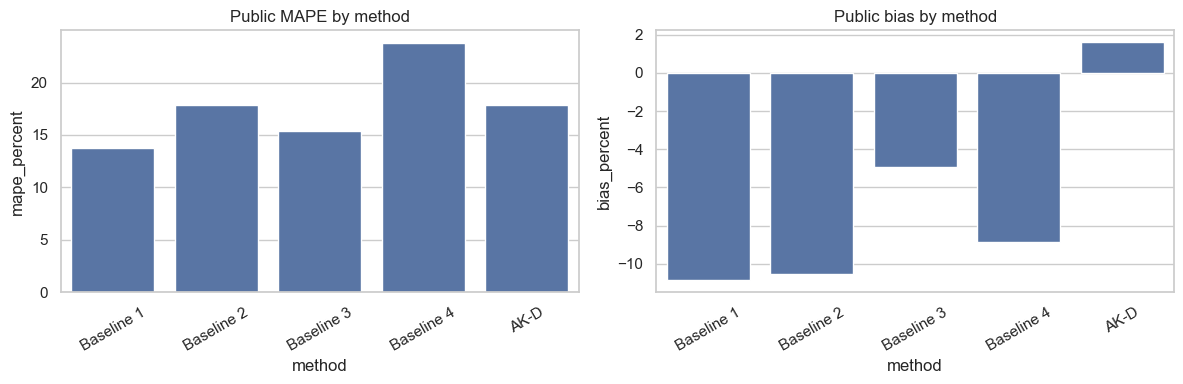

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=public_metrics, x='method', y='mape_percent', ax=axes[0])
sns.barplot(data=public_metrics, x='method', y='bias_percent', ax=axes[1])
for axis in axes:
    axis.tick_params(axis='x', rotation=30)
axes[0].set_title('Public MAPE by method')
axes[1].set_title('Public bias by method')
fig.tight_layout()

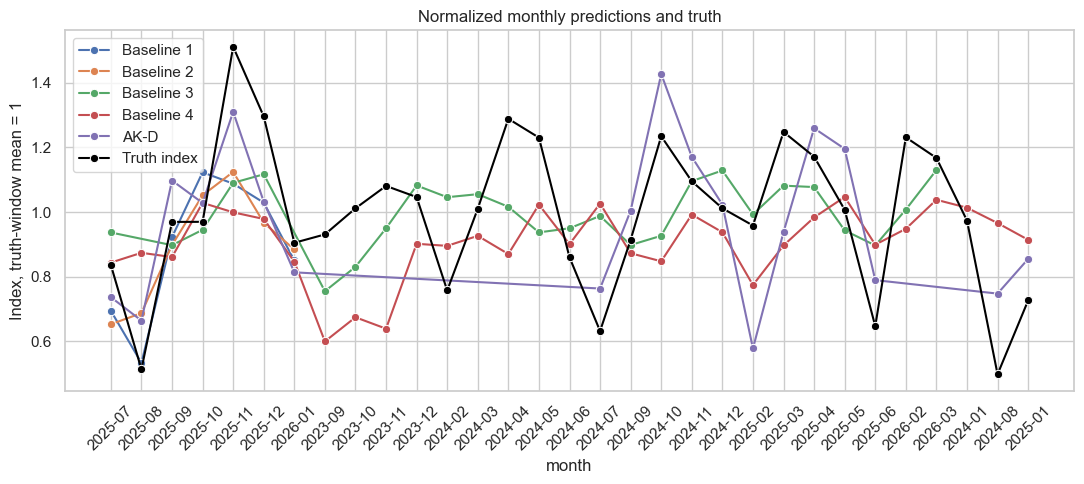

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=public_monthly, x='month', y='energy_pred_index', hue='method', marker='o', ax=ax)
sns.lineplot(data=public_monthly.drop_duplicates('month'), x='month', y='energy_true_index', color='black', marker='o', label='Truth index', ax=ax)
ax.tick_params(axis='x', rotation=45)
ax.set_title('Normalized monthly predictions and truth')
ax.set_ylabel('Index, truth-window mean = 1')
fig.tight_layout()

## 7. Actual Public Figures

下面几张图由真实评估结果和真实中间指标渲染，公开仓库只保留 PNG 与脱敏指标，不保留原始电量表、风塔表或本地路径。

![Baseline MAPE and bias](../figures/point_forecast/actual_baseline_mape_bias.png)

MAPE 反映逐月误差大小，Bias 反映整体高估或低估。Baseline 1/2 是历史类参照，Baseline 3/4 是 EC45 预报驱动路线，AK-D 是分月订正路线。看这张图时不要只看 MAPE，也要看 Bias 是否长期偏一侧。

![Monthly prediction index](../figures/point_forecast/actual_monthly_prediction_index.png)

这张图把真实电量和各方法预测都转成指数。它主要用来观察趋势跟随：某些方法总量偏差不大，但逐月峰谷跟不住；这会在调度或月度经营分析里造成问题。

![Monthly relative error heatmap](../figures/point_forecast/actual_monthly_error_heatmap.png)

热力图用于定位异常月份。颜色连续偏红或偏蓝，说明方法存在系统性偏差；只有个别月份颜色很深，则更可能是风况异常、覆盖不足或该月订正规则不适配。

![Lead-day error and correlation](../figures/point_forecast/actual_forecast_lead_day_error.png)

提前期图只对 Baseline 3/4 展开，因为它们依赖 EC45 起报和提前期。它用来判断预报越远时误差是否放大、相关性是否衰减，也能解释为什么最终月度点预测不能只看单日预报表现。

## 8. Conclusion

从真实脱敏结果看，5 条最终点预测基线覆盖了从朴素历史同期、气候库功率曲线、EC45 订正、相似日，到 AK-D 分月订正的完整路线。AK-D 的价值是说明订正系数按月份拆分后，部分极端月份误差会回落；它仍需要关注分月样本少导致的过修正。